# Quantitative Trading Back-testing Summer Project: #

## SPY Moving Average Crossover Strategy Analysis — 2010 to 2024

This notebook implements and evaluates a systematic momentum-based 
trading strategy on SPY (S&P 500 ETF) using a moving average 
crossover signal. The analysis follows the methodology outlined 
in Chan (2013) and covers

1. Data acquisition and statistical characterisation
2. Statistical tests for mean reversion vs momentum
3. Signal generation and strategy development
4. Backtesting with realistic transaction costs
5. Performance evaluation across multiple metrics
6. Walk-forward testing for out-of-sample validation

---

**Key Finding:**
\
The MA 50/200 (Golden Cross) long-only crossover strategy achieves a Sharpe Ratio of of 0.490 in-sample and 0.410 
out-of-sample, compared to buy and hold at 0.623. While underperforming significantly on raw returns compared to buy-and-hold, the strategy demonstrates genuine out-of-sample robustness and reduced volatility


In [1]:
import sys
sys.path.append('..')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


#Importing analysis modules
from src.data_pipeline import load_data
from src.features import add_all_features, adf_test, hurst_exponent
from src.backtester import run_backtest, split_in_out_sample
from src.features import add_all_features
from src.signals import ma_crossover_signal
from src.signals import ma_crossover_long_only
from src.metrics import compute_all_metrics
from src.visualisation import (
    plot_price_and_returns,
    plot_returns_distribution,
    plot_signals,
    plot_cumulative_returns,
    plot_drawdown,
    plot_monthly_returns_heatmap,
    plot_walk_forward_comparison,
    plot_metrics_comparison
)
from src.metrics import (monte_carlo_sharpe, plot_monte_carlo)

# Load SPY data
df = load_data('SPY', '2010-01-01', '2024-01-01')

# Basic inspection
print(df.shape)
print(df.head())
print(df.describe())

[*********************100%***********************]  1 of 1 completed

Downloaded 3522 rows of data
(3521, 6)
                Close       High        Low       Open     Volume  log_returns
Date                                                                          
2010-01-05  84.802361  84.839678  84.220245  84.526232  111579900     0.002643
2010-01-06  84.862061  85.071024  84.653097  84.720261  116074400     0.000704
2010-01-07  85.220306  85.324788  84.466539  84.705356  131091100     0.004213
2010-01-08  85.503876  85.541193  84.824743  84.996390  126402800     0.003322
2010-01-11  85.623276  85.921792  85.257583  85.884480  106375700     0.001395
             Close         High          Low         Open        Volume  \
count  3521.000000  3521.000000  3521.000000  3521.000000  3.521000e+03   
mean    224.239661   225.441578   222.855647   224.197963  1.156964e+08   
std     109.792779   110.450656   109.051391   109.770166  6.969748e+07   
min      76.950600    77.869189    76.144933    77.635779  2.027000e+07   
25%     132.128754   132.778327  

# 1: Data Exploration and Statistical Characterisation #

SPY (SPDR S&P 500 ETF Trust) tracks the S&P 500 index — the 500 largest publicly listed US companies.

To begin with, we visualise the price series and daily log returns, then compute distributional statistics. Log returns are used throughout in preference to simple returns as they are additive across time and better behaved statistically (Hull, 2018). 

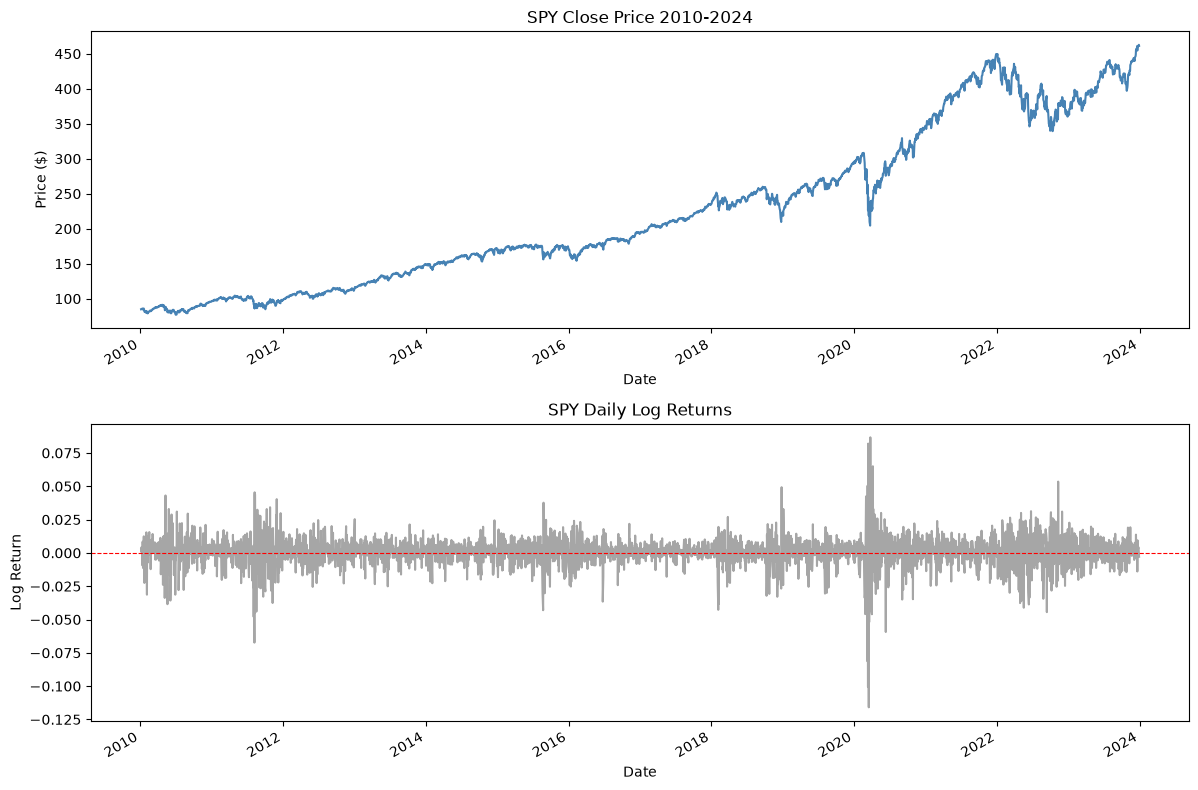

In [2]:
# Plot the price series
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

df['Close'].plot(ax=ax1, title='SPY Close Price 2010-2024', color='steelblue')
ax1.set_ylabel('Price ($)')

df['log_returns'].plot(ax=ax2, title='SPY Daily Log Returns', color='grey', alpha=0.7)
ax2.set_ylabel('Log Return')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

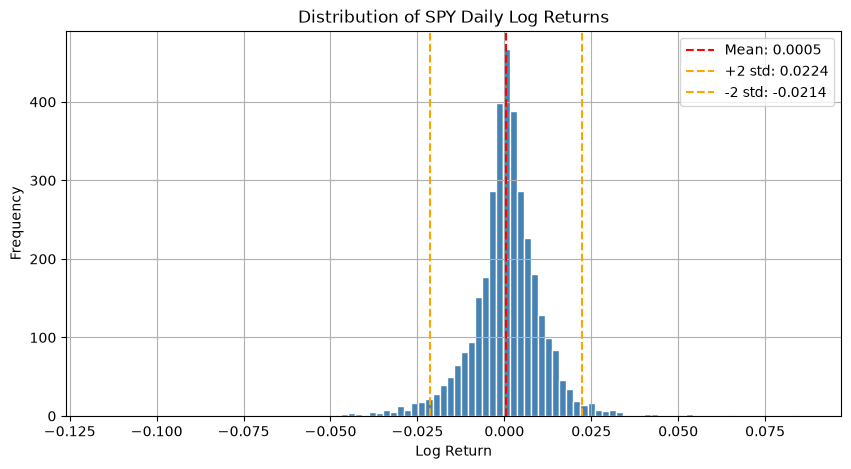

Mean daily return: 0.0005
Daily volatility: 0.0109
Annualised volatility: 0.1738
Skewness: -0.7178
Kurtosis: 11.5115


In [3]:
# Distribution of returns

fig, ax = plt.subplots(figsize=(10, 5))
df['log_returns'].hist(bins=100, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Distribution of SPY Daily Log Returns')
ax.set_xlabel('Log Return')
ax.set_ylabel('Frequency')

# Add mean and std lines
mean = df['log_returns'].mean()
std = df['log_returns'].std()
ax.axvline(mean, color='red', linestyle='--', label=f'Mean: {mean:.4f}')
ax.axvline(mean + 2*std, color='orange', linestyle='--', label=f'+2 std: {mean+2*std:.4f}')
ax.axvline(mean - 2*std, color='orange', linestyle='--', label=f'-2 std: {mean-2*std:.4f}')
ax.legend()
plt.show()

print(f"Mean daily return: {mean:.4f}")
print(f"Daily volatility: {std:.4f}")
print(f"Annualised volatility: {std * np.sqrt(252):.4f}")
print(f"Skewness: {df['log_returns'].skew():.4f}")
print(f"Kurtosis: {df['log_returns'].kurtosis():.4f}")

### Comments: ###

1. Price (top-plot): long upward trend from $\$ 90$ in 2010 to  $\$ 450$ in 2024 - SPY is a strongly trending asset over this period. A momentum/trend-following strategy has a natural tailwind on this asset, while a pure mean reversion strategy on price levels would have been disastrous. The sharp drop in 2020 was due to the COVID crash.
2. Returns Chart: clustering of volatility is very evident - calm periods before explosive periods (called volatility clustering - a very well established fact in financial data). A very large spike in 2020 - a strategy that survives 2020 is significantly more robust than one that doesn't.
3. Distribution statistics:
   - Mean daily return: 0.0005 (roughly 12.6% annualised — consistent with S&P 500 long run returns)
   - Annualised volatility: 17.38% — typical for the S&P 500
   - Skewness: -0.7178 — negative skew means large negative returns happen more often than large positive returns of the same magnitude.       This is the classic equity market property — markets fall faster than they rise
   Kurtosis: 11.51 — this is the most important number. A normal distribution has kurtosis of 3. Value of 11.51 means the distribution    has extremely fat tails — large moves happen far more often than a normal distribution would predict. Therefore, financial returns are very emphatically NOT normally distributed. Any strategy evaluation that assumes normality is understating tail risk. As a result, we should not use Sharpe Ratio but instead Sortino ratio - treats downside volatility separately rather than assuming symmetry. 

## 2. Asset Selection and Statistical Analysis: Testing for Mean-reversion ##

Before implementing any strategy, we test whether SPY exhibits mean reversion using two established methods from Chan (2013):

- **Augmented Dickey-Fuller (ADF) test**: Tests for a unit root (non-stationarity). p-value below 0.05 rejects the null hypothesis of a unit root, suggesting mean reversion.
- **Hurst exponent**: H < 0.5 indicates mean reversion, H = 0.5 a random walk, H > 0.5 trending behaviour.

These tests directly determine which type of strategy is statistically appropriate for this asset.

*References: Dickey & Fuller (1979); Chan (2013), Chapter 2.*

In [4]:
# Add features
df_features = add_all_features(df)
print(f"Shape after adding features: {df_features.shape}")
print(df_features[['Close', 'sma_20', 'sma_50', 
                     'momentum_20', 'volatility_20']].tail())

Shape after adding features: (3472, 10)
                 Close      sma_20      sma_50  momentum_20  volatility_20
Date                                                                      
2023-12-22  459.779938  448.440353  431.322427     0.043558       0.005950
2023-12-26  461.721313  449.556927  432.213396     0.049574       0.005890
2023-12-27  462.556183  450.693495  433.033278     0.050391       0.005882
2023-12-28  462.730927  451.854268  433.857041     0.051473       0.005856
2023-12-29  461.391296  452.861530  434.766354     0.044644       0.005971


In [5]:
# Test 1: Is the SPY price series mean-reverting?
adf_price = adf_test(df_features['Close'], name='SPY Price')

# Test 2: Are the log returns mean-reverting?
adf_returns = adf_test(df_features['log_returns'], name='SPY Log Returns')

# Test 3: Hurst exponent on price
h_price = hurst_exponent(df_features['Close'])

# Test 4: Hurst exponent on returns  
h_returns = hurst_exponent(df_features['log_returns'])


ADF Test — SPY Price
  Test statistic : 0.6301
  p-value        : 0.9883
  Mean-reverting : False

ADF Test — SPY Log Returns
  Test statistic : -12.7941
  p-value        : 0.0
  Mean-reverting : True

Hurst Exponent: 0.4076
  Interpretation: Mean reverting

Hurst Exponent: -0.0011
  Interpretation: Mean reverting


### Comments: ###
The ADF test on the price series yielded p = 0.99, confirming the price is non-stationary and not suitable for mean reversion strategies. The Hurst exponent of 0.41 on the price series confirms mild but insufficient mean reversion. Based on this analysis, a momentum-based moving average crossover strategy was selected as statistically appropriate for this asset.

#### Justification: ####
SPY price is not mean-reverting enough to profitably trade mean reversion strategies on directly. The moving average crossover momentum strategy you're building is therefore the appropriate choice for this asset — you're following the trend rather than betting against it, which is consistent with what the data actually shows.

Therefore, a moving average crossover momentum strategy is the appropraite choice for this asset - following the trend rather than betting against it. 


*Note: I am using the workflow described by Ernest Chan's "Algorithmic Trading" book - test the asset first, then choose the strategy based on evidence.*

## 3. Signal Genreation and Feature engineering: ##

The previous tests confirm that SPY is non-stationary and has a mildly trending nature; thus, we implement a moving average crossover strategy. A moving crossover strategy uses two moving averages of different lengths (one fast, one slow) to generate buy and sell signals. A buy signal occurs when the fast moving average (MA) crosses above the slow MA, and a sell signal occurs when the fast MA crosses below the slow MA. A fast MA reacts quickly to recent price changes and a slow MA reacts slowly to price changes, smoothing the data to show the underlying trend.

Three variants are compared:
- **MA 20/50 Long/Short**: Long when SMA20 > SMA50, short otherwise
- **MA 20/50 Long-Only**: Long when SMA20 > SMA50, flat otherwise
- **MA 50/200 Golden Cross**: Long when SMA50 > SMA200, flat otherwise

**Look-ahead bias prevention**: All signals use `.shift(1)` to 
ensure signals from day T prices only execute on day T+1 (Chan, 2013)

*Reference: Chan (2013), Chapter 3; Murphy (1999), Chapter 9.*


Signal Distribution:
  Long  (+1): 2462 days (70.9%)
  Flat   (0): 0 days (0.0%)
  Short (-1): 1009 days (29.1%)
  Total     : 3471 days


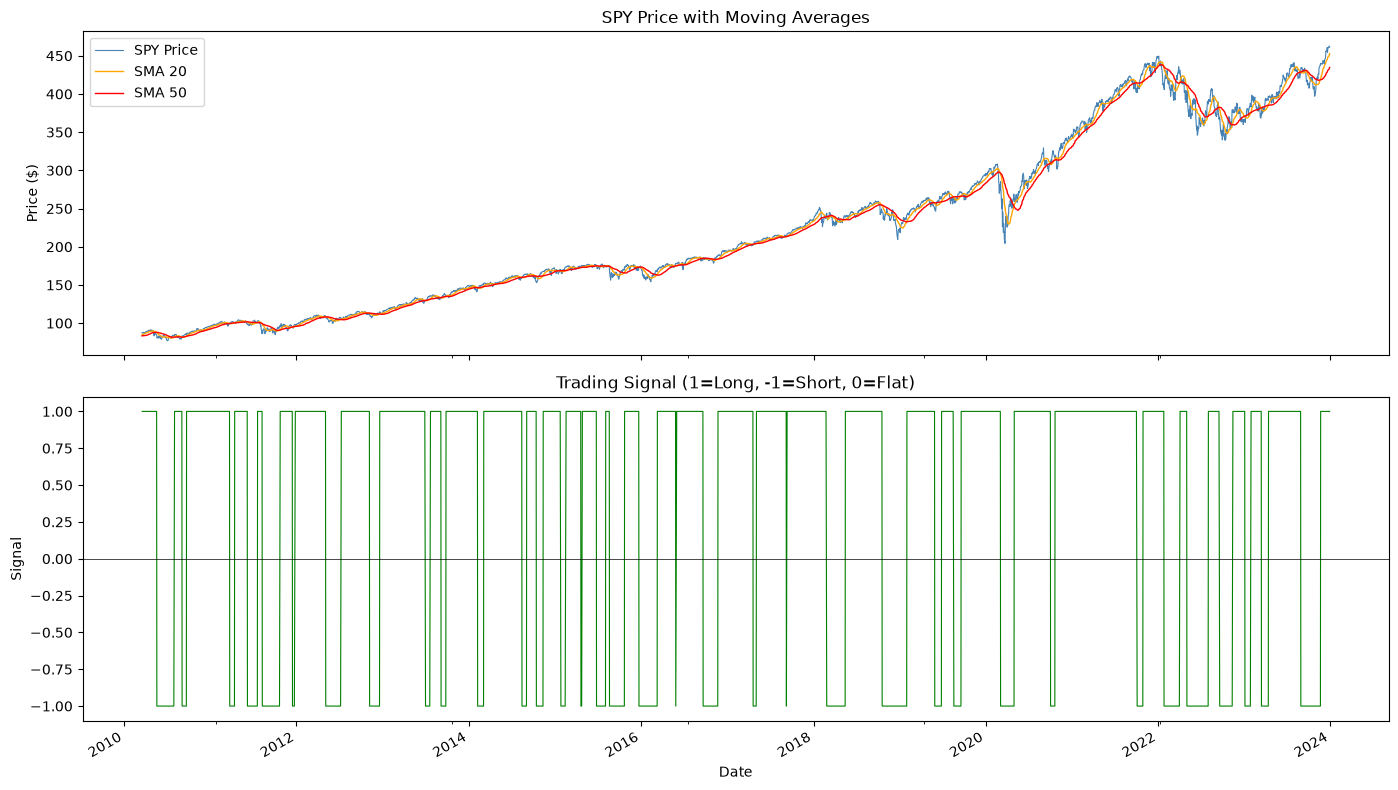

In [6]:
from src.signals import ma_crossover_signal, signal_summary
from src.features import add_all_features

# Generate signals
df_features = add_all_features(df)
signal = ma_crossover_signal(df_features, fast=20, slow=50)

# Check signal distribution
signal_summary(signal)

# Plot price with signals overlaid
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Price with moving averages
df_features['Close'].plot(ax=ax1, color='steelblue', 
                           linewidth=0.8, label='SPY Price')
df_features['sma_20'].plot(ax=ax1, color='orange', 
                            linewidth=1, label='SMA 20')
df_features['sma_50'].plot(ax=ax1, color='red', 
                            linewidth=1, label='SMA 50')
ax1.set_title('SPY Price with Moving Averages')
ax1.set_ylabel('Price ($)')
ax1.legend()

# Signal over time
signal.plot(ax=ax2, color='green', linewidth=0.8)
ax2.set_title('Trading Signal (1=Long, -1=Short, 0=Flat)')
ax2.set_ylabel('Signal')
ax2.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

### Commments: ###

1. __Signal Distribution - 70.9% Long and 29.1% Short__
- This makes sense given what we already know about SPY. It's been in a generally upward trend from 2010-2024, so a momentum strategy naturally spends more time long than it does short

2. __Signal Plot__
- Signal switches cleanly between +1 and -1 which is expected for a simple crossover -> either the 20-day SMA (Simple Moving Average) is always above or below the 50-day SMA. During the long bull (prices are steadily climing and the economy is looking overall strong) run from 2012-2018 the signal is predominantly long, and it flips short during the 2020 crash and the 2022 bear (prices are falling sharply - often triggered by economic slowdowns, recessions, or geopolitical crises) market. There are also choppy periods like 2011 and 2015-2016. Each flip incurs a transation cost (whipsawing). 
   

## 4. Back-testing the Strategy: ##

The backtesting engine simulates trading each strategy on 
historical data with:
- **Transaction costs**: 0.1% per trade (realistic for liquid ETFs)
- **Log returns**: Used throughout for mathematical consistency
- **Benchmark**: Buy and hold SPY as the primary comparison

=== Data Split ===
In-sample     : 2010-03-18 to 2018-12-31 (2213 days)
Out-of-sample : 2019-01-02 to 2023-12-29 (1258 days)

=== Full Period Backtest ===
Backtest complete:
  Period        : 2010-03-18 to 2023-12-29
  Trading days  : 3471
  Num trades    : 70
  Total costs   : 0.1400 (14.00%)


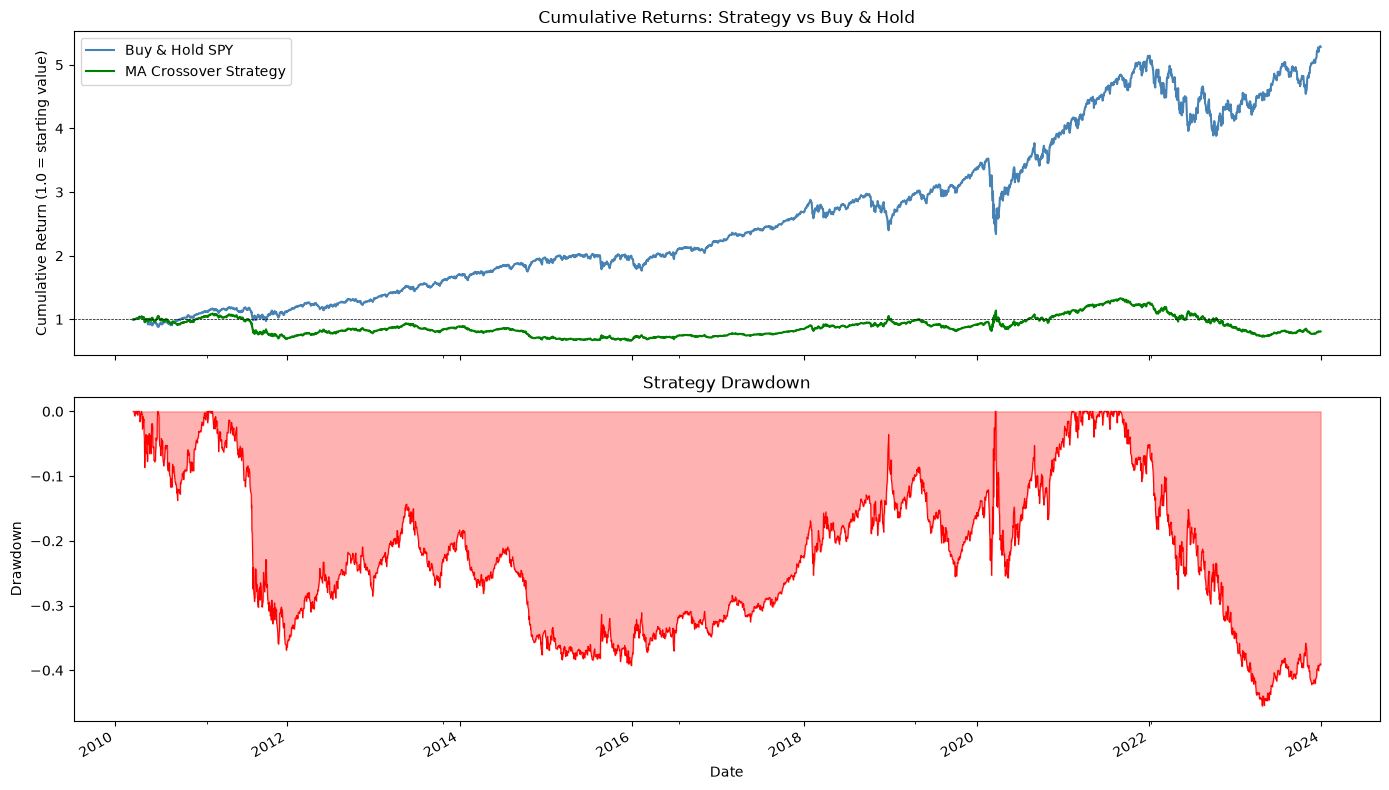


Final Results:
  Buy & Hold return : 428.0%
  Strategy return   : -19.1%


In [7]:
# Prepare data
df_features = add_all_features(df)

# Generate signal and add it as a column to df_features
signal = ma_crossover_signal(df_features, fast=20, slow=50)
df_features['signal'] = signal

# Drop any rows with NaN in critical columns
df_features = df_features.dropna(subset=['signal', 'log_returns'])

# Split into in-sample and out-of-sample
print("=== Data Split ===")
in_sample, out_of_sample = split_in_out_sample(df_features)

# Run backtest on full period
print("\n=== Full Period Backtest ===")
results = run_backtest(df_features, df_features['signal'], 
                       transaction_cost=0.001)

# Plot results
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Cumulative returns
results['cumulative_market'].plot(ax=ax1, label='Buy & Hold SPY',
                                   color='steelblue', linewidth=1.5)
results['cumulative_strategy'].plot(ax=ax1, label='MA Crossover Strategy',
                                     color='green', linewidth=1.5)
ax1.set_title('Cumulative Returns: Strategy vs Buy & Hold')
ax1.set_ylabel('Cumulative Return (1.0 = starting value)')
ax1.legend()
ax1.axhline(y=1.0, color='black', linewidth=0.5, linestyle='--')

# Drawdown
rolling_max = results['cumulative_strategy'].cummax()
drawdown = (results['cumulative_strategy'] - rolling_max) / rolling_max
drawdown.plot(ax=ax2, color='red', linewidth=0.8)
ax2.set_title('Strategy Drawdown')
ax2.set_ylabel('Drawdown')
ax2.fill_between(drawdown.index, drawdown, 0, alpha=0.3, color='red')

plt.tight_layout()
plt.show()

# Print final cumulative returns
print(f"\nFinal Results:")
print(f"  Buy & Hold return : "
      f"{(results['cumulative_market'].iloc[-1] - 1)*100:.1f}%")
print(f"  Strategy return   : "
      f"{(results['cumulative_strategy'].iloc[-1] - 1)*100:.1f}%")



### Comments: ###

The strategy significantly underperformed buy and hold. 
1. Transation costs are extremely high, $14\%$, the strategy kept flipping in choppy markets (whipsawing seen in the previous signal plots), paying costs each time without capturing any trends.
2. The short positions hurt badly during the bull market - when the strategy goes short (-1), it bets SPY will fall. But SPY spent most of 2010-2024 as a strong bull market. Therefore, every time the strategy went short during an upward trend, the strategy lost money. The drawndown chart (percentage decline in trading strategy from its previous peak) displays that the strategy was in continuous drawdown for most of the period and never fully recovered.


#### Improvements: ####
1. The applied strategy could remove selling at the short positions entirely; instead of selling at short positions (-1), go flat (hold at short positions).
2. Increase the size of the window from between 20-day SMA and 50-day SMA (20/50) to 50-day SMA to 200-day SMA (50/200 - Golden Cross). This will result in fewer trades and lower costs, and the strategy will only react to major trends. 


In [8]:
## Improvement to ma crossover model added where buying is only done in long positions and short positions cash is held

# Test 1: Long-only with 20/50
signal_long_only = ma_crossover_long_only(df_features, fast=20, slow=50)
df_features['signal'] = signal_long_only
results_long_only = run_backtest(df_features, 
                                  df_features['signal'],
                                  transaction_cost=0.001)

# Test 2: Long-only with 50/200 (Golden Cross)
df_features_200 = add_all_features(df, 
                                    ma_windows=[50, 200],
                                    mom_windows=[20])
signal_golden = ma_crossover_long_only(df_features_200, fast=50, slow=200)
df_features_200['signal'] = signal_golden
results_golden = run_backtest(df_features_200,
                               df_features_200['signal'],
                               transaction_cost=0.001)


Backtest complete:
  Period        : 2010-03-19 to 2023-12-29
  Trading days  : 3470
  Num trades    : 35
  Total costs   : 0.0700 (7.00%)
Backtest complete:
  Period        : 2010-10-20 to 2023-12-29
  Trading days  : 3321
  Num trades    : 6
  Total costs   : 0.0120 (1.20%)


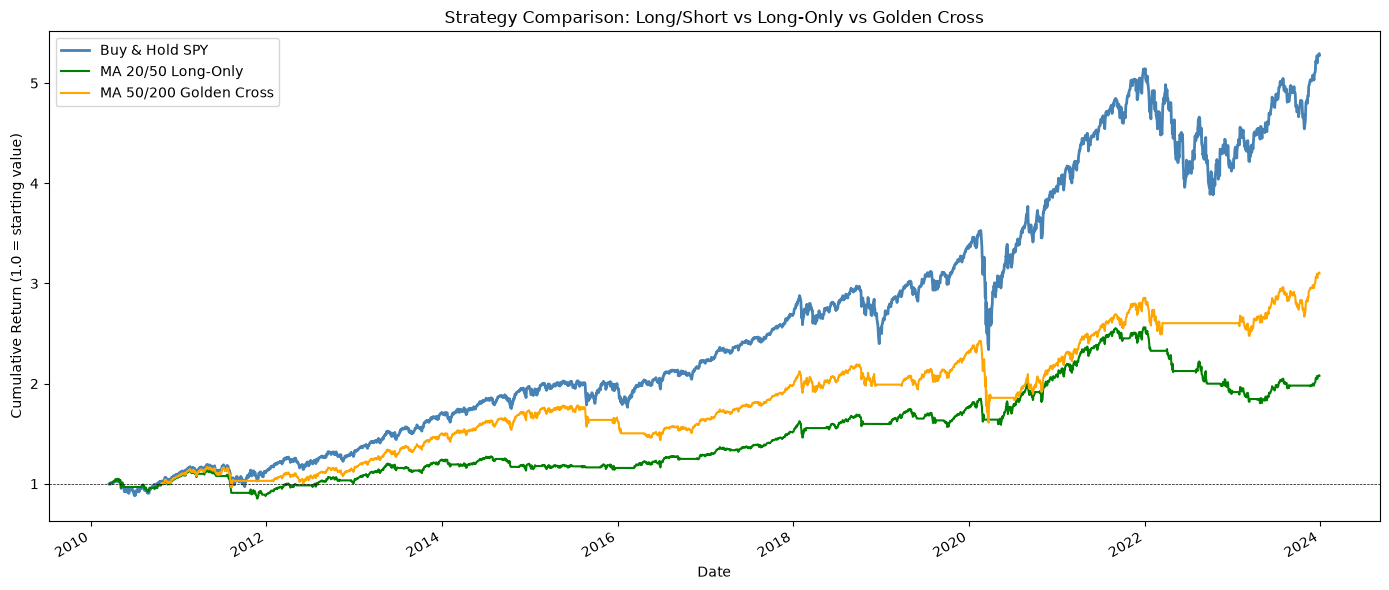


Strategy Comparison:
  Buy & Hold         : 428.0%
  MA 20/50 L/S       : -19.1%
  MA 20/50 Long-Only : 107.8%
  MA 50/200 Golden X : 210.1%


In [9]:
# Plot all three together
fig, ax = plt.subplots(figsize=(14, 6))

results['cumulative_market'].plot(ax=ax, label='Buy & Hold SPY',
                                   color='steelblue', linewidth=2)
results_long_only['cumulative_strategy'].plot(
    ax=ax, label='MA 20/50 Long-Only',
    color='green', linewidth=1.5)
results_golden['cumulative_strategy'].plot(
    ax=ax, label='MA 50/200 Golden Cross',
    color='orange', linewidth=1.5)

ax.set_title('Strategy Comparison: Long/Short vs Long-Only vs Golden Cross')
ax.set_ylabel('Cumulative Return (1.0 = starting value)')
ax.legend()
ax.axhline(y=1.0, color='black', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.show()

# Print comparison
print("\nStrategy Comparison:")
print(f"  Buy & Hold         : "
      f"{(results['cumulative_market'].iloc[-1]-1)*100:.1f}%")
print(f"  MA 20/50 L/S       : "
      f"{(results['cumulative_strategy'].iloc[-1]-1)*100:.1f}%")
print(f"  MA 20/50 Long-Only : "
      f"{(results_long_only['cumulative_strategy'].iloc[-1]-1)*100:.1f}%")
print(f"  MA 50/200 Golden X : "
      f"{(results_golden['cumulative_strategy'].iloc[-1]-1)*100:.1f}%")

### Comments: ###

There is a clear improvement with using a strategy that holds on short positions, with MA 50/200 Golden X showing much higher profitability than M20/50 Long-only. This is because the 50/200 strategy trades far less frequently causing it to only react to long-term major trend changes rather than short-term noise, which leads to lower transaction costs and less whipsawing in choppy markets. 

Both strategies still significantly underperform buy and hold SPY. 

A useful thing to note: during 2020 the buy and hold line crashes sharply down and recovers, while the orange MA 50/200 line flattens duing the 2020 crash. Thus during a major drawdown, this strategy was able to avoid the worst of a major drawdown. 

## 5. Performance Metrics

Five risk-adjusted metrics are computed for each strategy:

| Metric | Description | Reference |
|---|---|---|
| Sharpe Ratio | Excess return per unit of total volatility | Sharpe (1994) |
| Sortino Ratio | Excess return per unit of downside volatility | Sortino & van der Meer (1991) |
| Calmar Ratio | Annualised return / max drawdown | Young (1991) |
| Max Drawdown | Largest peak-to-trough decline | Magdon-Ismail & Atiya (2004) |
| Win Rate | Fraction of active days with positive return | Pardo (2008) |




*Note: Given SPY's kurtosis of 11.5 (vs 3.0 for a normal 
distribution), the Sortino ratio is more appropriate than Sharpe 
as it does not assume return symmetry.*

In [10]:
# Metrics for each strategy
metrics_ls = compute_all_metrics(results, 
                                  label='MA 20/50 Long/Short')
metrics_lo = compute_all_metrics(results_long_only, 
                                  label='MA 20/50 Long-Only')
metrics_gc = compute_all_metrics(results_golden, 
                                  label='MA 50/200 Golden Cross')

# Also compute buy and hold metrics for comparison
results_bh = results.copy()
results_bh['strategy_returns_net'] = results_bh['log_returns']
results_bh['cumulative_strategy'] = results_bh['cumulative_market']
results_bh['signal'] = 1
results_bh['position_change'] = 0
metrics_bh = compute_all_metrics(results_bh, 
                                  label='Buy & Hold SPY')


  Performance Metrics — MA 20/50 Long/Short
  Total Return          : -19.1%
  Benchmark Return      : 428.0%
  Annualised Return     : -1.5%
  Annualised Volatility : 17.4%
  Max Drawdown          : -45.5%
  Sharpe Ratio          : -0.202
  Sortino Ratio         : -0.259
  Calmar Ratio          : -0.033
  Win Rate              : 51.4%
  Number of Trades      : 70

  Performance Metrics — MA 20/50 Long-Only
  Total Return          : 107.8%
  Benchmark Return      : 428.2%
  Annualised Return     : 5.5%
  Annualised Volatility : 11.7%
  Max Drawdown          : -29.6%
  Sharpe Ratio          : 0.295
  Sortino Ratio         : 0.301
  Calmar Ratio          : 0.184
  Win Rate              : 54.5%
  Number of Trades      : 35

  Performance Metrics — MA 50/200 Golden Cross
  Total Return          : 210.1%
  Benchmark Return      : 422.2%
  Annualised Return     : 9.0%
  Annualised Volatility : 14.2%
  Max Drawdown          : -33.7%
  Sharpe Ratio          : 0.490
  Sortino Ratio         : 0

### Important Observations: ###

1. **Buy and Hold has the best Sharp Ratio - but not by as much as the raw returns suggests**. Buy and Hold Sharpe is 0.623 and MA 50/200 Sharpe is 0.490. The gap in risk-adjusted terms is much smaller than the raw return gap froom both strategies, 428% and 210.1% respectively, demonstrate. Thus, we can see that the MA 50/200 strategy trades a reduced return to optimise for reduced risk.
2. **MA 50/200 has identical max drawdown to buy and hold at $33.7\%$.**
3. **Win-rate is about the same across all strategies.** All strategies win on roughly 55% of trading days. The huge disparity in returns across the strategies therefore is determined not by when they win/lose, but rather by how much the win when they win and how much they lose when they lose. This is most clear with the win-rate of the MA 20/50 Long/Short strategy having a winrate of $51.4\% $ despite having a raw returns of $-19\% $.

Overall, simply moving average crossover strategies struggle to beat a diversified index ETF in prolonged bull market. 

## 6. Walk-forward Testing: ##

Walk-forward testing splits data into two non-overlapping periods to assess genuine out-of-sample robustness:

- **In-sample (2010-2018)**: Training period — 2,213 trading days
- **Out-of-sample (2019-2024)**: Test period — 1,258 trading days
  
The out-of-sample period deliberately includes the 2020 COVID crash and 2022 bear market — genuinely difficult conditions that differ from the 2010-2018 bull market training period.

*References: Chan (2013), pp. 67-71; López de Prado (2018), Ch. 7.*

In [11]:
# Use the Golden Cross as our primary strategy going forward
# as it showed the best risk-adjusted performance

# Split data
in_sample, out_of_sample = split_in_out_sample(df_features)

# Add features to each period separately
in_sample_feat = add_all_features(in_sample, ma_windows=[50, 200])
out_sample_feat = add_all_features(out_of_sample, ma_windows=[50, 200])

# Generate signals on each period separately
in_sample_feat['signal'] = ma_crossover_long_only(
    in_sample_feat, fast=50, slow=200)
out_sample_feat['signal'] = ma_crossover_long_only(
    out_sample_feat, fast=50, slow=200)

# Drop NaNs
in_sample_feat = in_sample_feat.dropna(subset=['signal', 'log_returns'])
out_sample_feat = out_sample_feat.dropna(subset=['signal', 'log_returns'])

# Run backtests on each period
print("=== IN-SAMPLE RESULTS (2010-2018) ===")
results_in = run_backtest(in_sample_feat, 
                           in_sample_feat['signal'],
                           transaction_cost=0.001)
metrics_in = compute_all_metrics(results_in, 
                                  label='Golden Cross In-Sample')

print("\n=== OUT-OF-SAMPLE RESULTS (2019-2024) ===")
results_out = run_backtest(out_sample_feat,
                            out_sample_feat['signal'],
                            transaction_cost=0.001)
metrics_out = compute_all_metrics(results_out,
                                   label='Golden Cross Out-of-Sample')

In-sample     : 2010-03-18 to 2018-12-31 (2213 days)
Out-of-sample : 2019-01-02 to 2023-12-29 (1258 days)
=== IN-SAMPLE RESULTS (2010-2018) ===
Backtest complete:
  Period        : 2010-12-31 to 2018-12-31
  Trading days  : 2013
  Num trades    : 3
  Total costs   : 0.0070 (0.70%)

  Performance Metrics — Golden Cross In-Sample
  Total Return          : 85.6%
  Benchmark Return      : 133.7%
  Annualised Return     : 8.0%
  Annualised Volatility : 12.3%
  Max Drawdown          : -19.5%
  Sharpe Ratio          : 0.490
  Sortino Ratio         : 0.547
  Calmar Ratio          : 0.413
  Win Rate              : 54.9%
  Number of Trades      : 3

=== OUT-OF-SAMPLE RESULTS (2019-2024) ===
Backtest complete:
  Period        : 2019-10-17 to 2023-12-29
  Trading days  : 1058
  Num trades    : 2
  Total costs   : 0.0040 (0.40%)

  Performance Metrics — Golden Cross Out-of-Sample
  Total Return          : 45.1%
  Benchmark Return      : 70.5%
  Annualised Return     : 9.3%
  Annualised Volatility :

### Commments: ###

*Note: A key limitation in this analysis is that only the 50/200 split was tested without changing the fast window or slow window parameters and determining the best walk forward result from there. A possible furture improvement would be to run a loop testing every single parameter combination with fast and slow window ranges between 20-300 and doing walk-foward testing on each combination and retrieve the most optimised result (this would generally be the case where both in-samplea and out-of-sample performances are quite similar)*

---
#### Observations: ####

1. Sharpe ratios are pretty similar in both the in-sample and out-of-sample tests, 0.490 and 0.410 respectively - a degradation of about 16%. This demonstrates that this strategy has genuine robustness.
2. The annualised returns increased from $8.0\%$ to $9.3\%$. This is an interesting result as the strategy returned a comparable annualised return from the out-of-sample test to the in-sample despite a more difficult market environment, considering the 2020 crash and the 2022 bear market. Thus, the strategy adds value during volatile regimes (in-sample volatilty and out-of-sample volatilty are $12.3\%$ and $17.1\%$ respectively).



# 7: Monte Carlo Significance Testing: #

In order to evluate whether the observed results from the strategy could have appeared by chance or not, we can use Monte Carlo permutation testing:

1. Record the strategy's actual Sharpe ratio (observed statistic)
2. Randomly shuffle the daily returns 10,000 times, breaking 
   any temporal structure
3. Compute the Sharpe ratio for each shuffled sequence
4. Compare the observed Sharpe ratio against this null distribution

If the actual Sharpe ratio exceeds the 95th percentile of the null distribution, there is statistical evidence (p < 0.05) that the strategy's performance is not due to lucky sequencing of returns. 

The Monte Carlo significance test was run with 10,000 simulations. Rather than shuffling returns, which would preserve the sum and produce identical Sharpe Ratios, the trading signal is shuffled. This randomly assigns when the strategy was long versus flat while preserving the same overall market exposure. 


In [16]:
# Run Monte Carlo test on Golden Cross strategy
print("Running Monte Carlo significance test (10,000 simulations)...")
mc_results = monte_carlo_sharpe(results_golden, n_simulations=10000)

print(f"\n=== Monte Carlo Results — Golden Cross 50/200 ===")
print(f"Observed Sharpe ratio  : {mc_results['observed_sharpe']:.4f}")
print(f"Mean null Sharpe       : {mc_results['mean_null']:.4f}")
print(f"Std null Sharpe        : {mc_results['std_null']:.4f}")
print(f"Percentile             : {mc_results['percentile']:.1f}%")
print(f"p-value                : {mc_results['p_value']:.4f}")
print(f"Statistically significant (p<0.05): {mc_results['significant']}")


Running Monte Carlo significance test (10,000 simulations)...

=== Monte Carlo Results — Golden Cross 50/200 ===
Observed Sharpe ratio  : 0.4901
Mean null Sharpe       : 0.0578
Std null Sharpe        : 0.1208
Percentile             : 100.0%
p-value                : 0.0002
Statistically significant (p<0.05): True


In [17]:
null = mc_results['null_sharpes']
print(f"Min: {null.min():.6f}")
print(f"Max: {null.max():.6f}")
print(f"Mean: {null.mean():.6f}")
print(f"Std: {null.std():.6f}")
print(f"Range: {null.max() - null.min():.6f}")
print(f"Observed: {mc_results['observed_sharpe']:.6f}")

Min: -0.344770
Max: 0.581304
Mean: 0.057817
Std: 0.120832
Range: 0.926073
Observed: 0.490101


Running in-sample Monte Carlo (10,000 simulations)...

=== Monte Carlo — In-Sample ===
Observed Sharpe  : 0.4903
95th percentile  : 0.3511
p-value          : 0.0038
Significant      : True


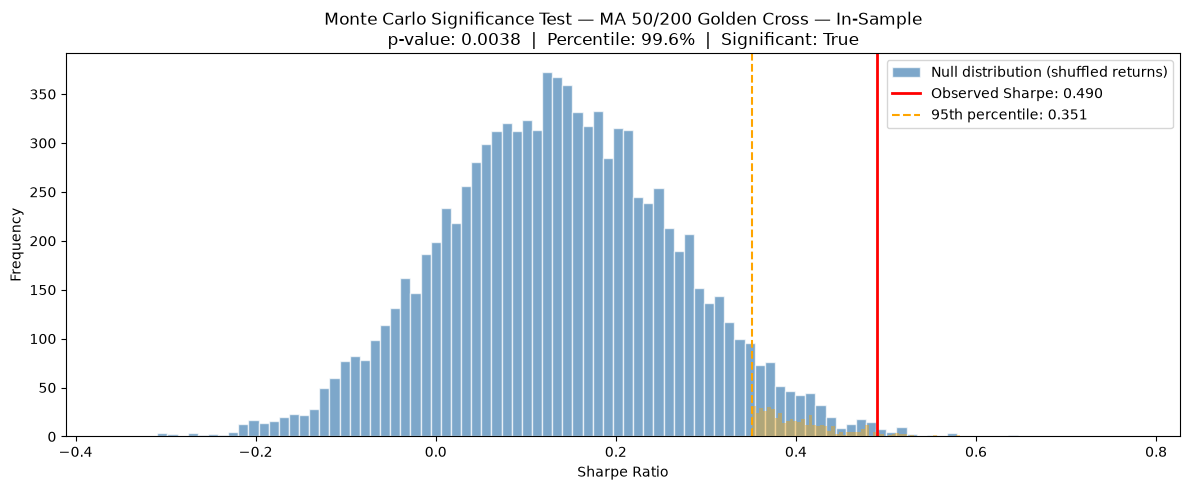

Saved: ./figures/monte_carlo_in_sample

Running out-of-sample Monte Carlo (10,000 simulations)...

=== Monte Carlo — Out-of-Sample ===
Observed Sharpe  : 0.4104
95th percentile  : 0.3036
p-value          : 0.0213
Significant      : True


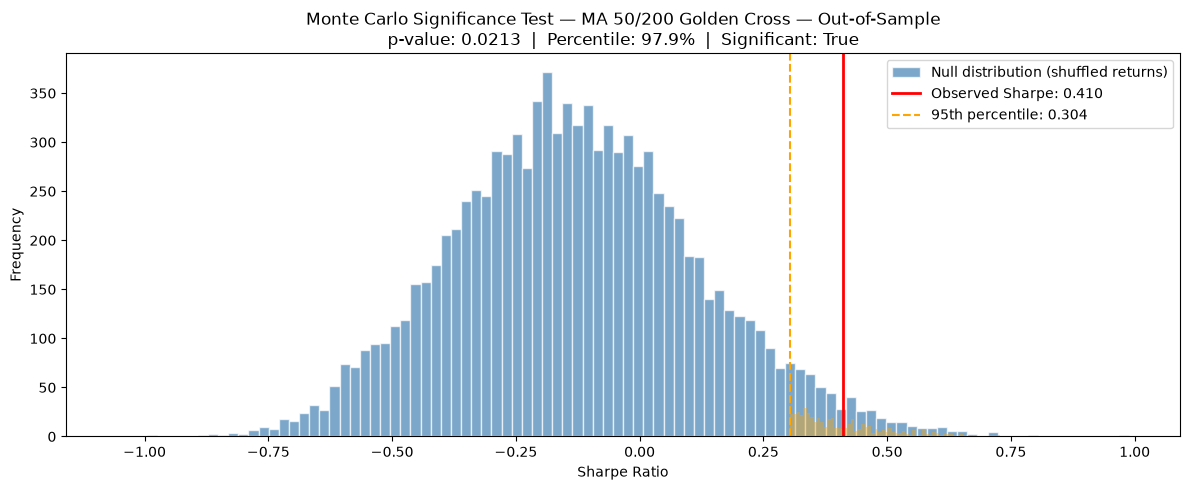

Saved: ./figures/monte_carlo_out_sample


In [19]:
SAVE_DIR = './figures/'

# In-sample Monte Carlo
print("Running in-sample Monte Carlo (10,000 simulations)...")
mc_in = monte_carlo_sharpe(results_in, n_simulations=10000)

print(f"\n=== Monte Carlo — In-Sample ===")
print(f"Observed Sharpe  : {mc_in['observed_sharpe']:.4f}")
print(f"95th percentile  : {np.percentile(mc_in['null_sharpes'], 95):.4f}")
print(f"p-value          : {mc_in['p_value']:.4f}")
print(f"Significant      : {mc_in['significant']}")

plot_monte_carlo(mc_in,
                  label='MA 50/200 Golden Cross — In-Sample',
                  save_dir=SAVE_DIR,
                fig_name= 'monte_carlo_in_sample')

# Out-of-sample Monte Carlo — separate null distribution
print("\nRunning out-of-sample Monte Carlo (10,000 simulations)...")
mc_out = monte_carlo_sharpe(results_out, n_simulations=10000)

print(f"\n=== Monte Carlo — Out-of-Sample ===")
print(f"Observed Sharpe  : {mc_out['observed_sharpe']:.4f}")
print(f"95th percentile  : {np.percentile(mc_out['null_sharpes'], 95):.4f}")
print(f"p-value          : {mc_out['p_value']:.4f}")
print(f"Significant      : {mc_out['significant']}")

plot_monte_carlo(mc_out,
                  label='MA 50/200 Golden Cross — Out-of-Sample',
                  save_dir=SAVE_DIR,
                fig_name = 'monte_carlo_out_sample')

## Results: ##

In the above Monte Carlo Plots, the sigficance tests are split between the in-sample and out-of-sample sets. 

The obtained p-value for the in-sample was 0.0038, which lies on the 99.6th percentile. The out-of-sample p-value was 0.0213, which lies on the 97.9th percentile. Thus, from the above result, we can reject the null hypothesis and confirm statistically significant timing skill on unseen data. 

The Monte Carlo test confirmed that the strategy's timing decisions (being long during uptrends and flat during downtrends) added measurable value beyond what one would get from randomly choosing when to be in the market.

## 8. Visualisations: ##

These are the final plots and visualisations that summarise the key findings determined by this investigation.



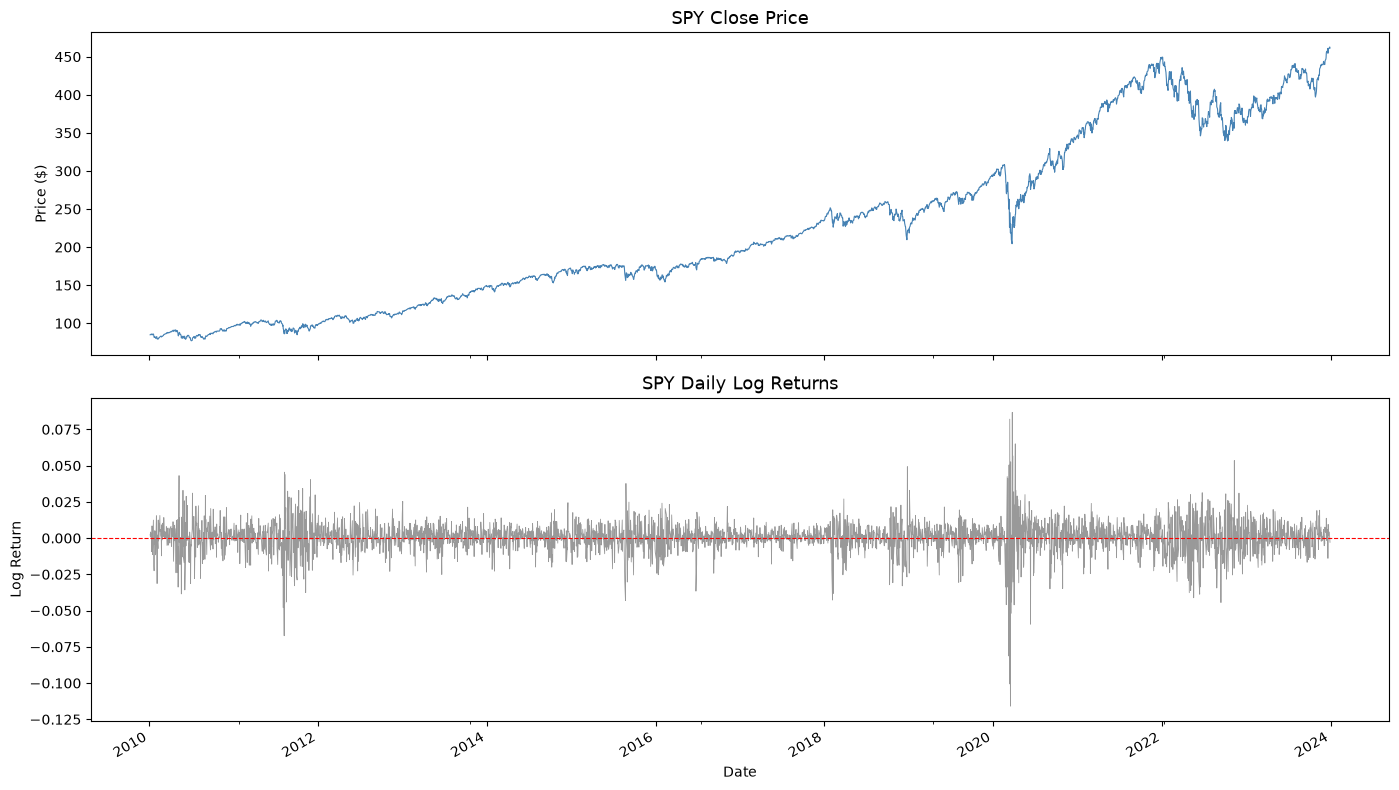

Saved: ./figures/price_and_returns.png


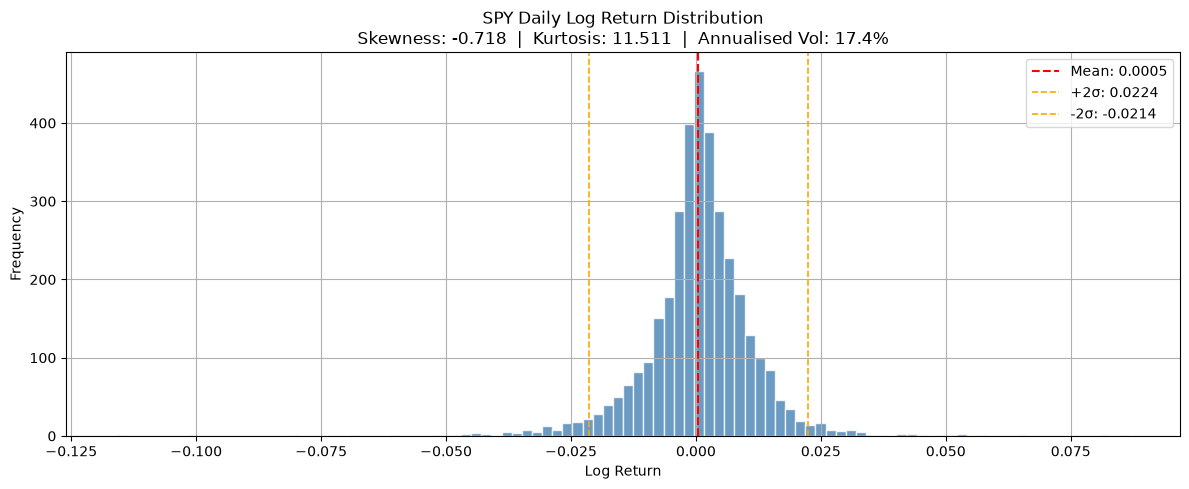

Saved: ./figures/returns_distribution.png


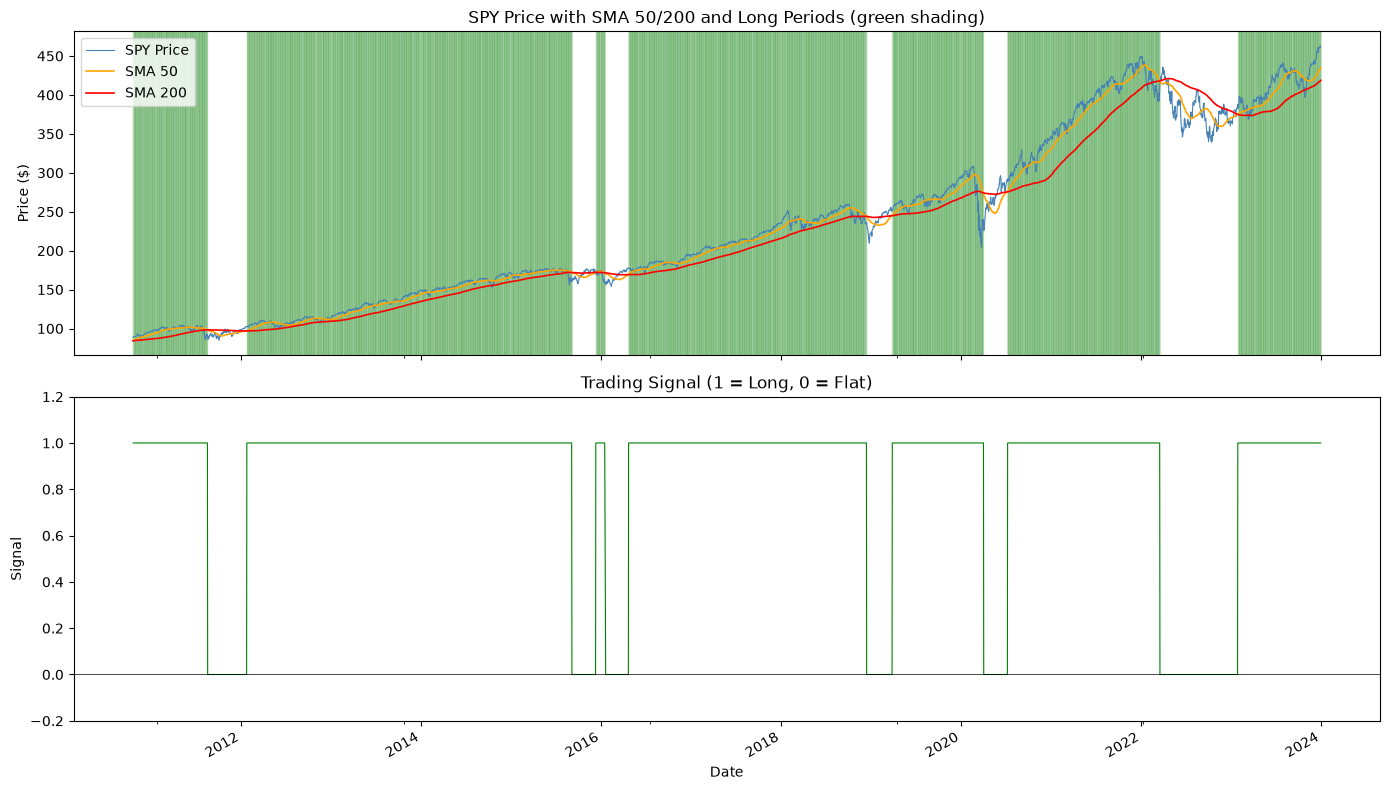

Saved: ./figures/signals.png


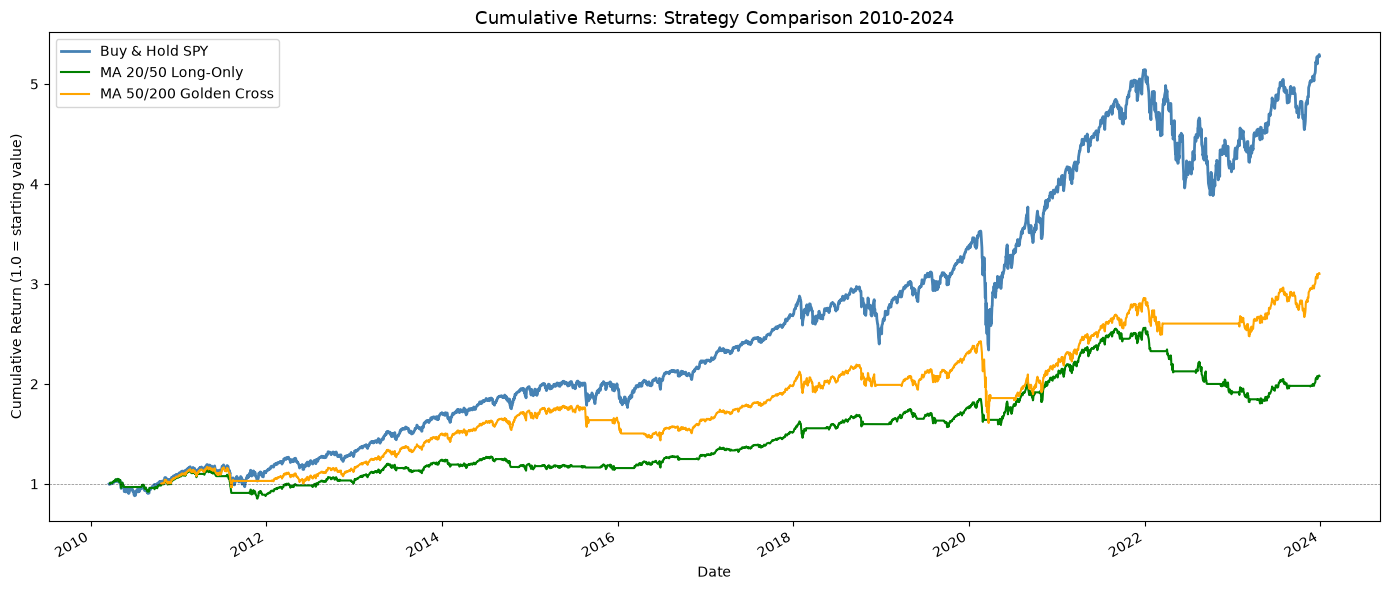

Saved: ./figures/cumulative_returns.png


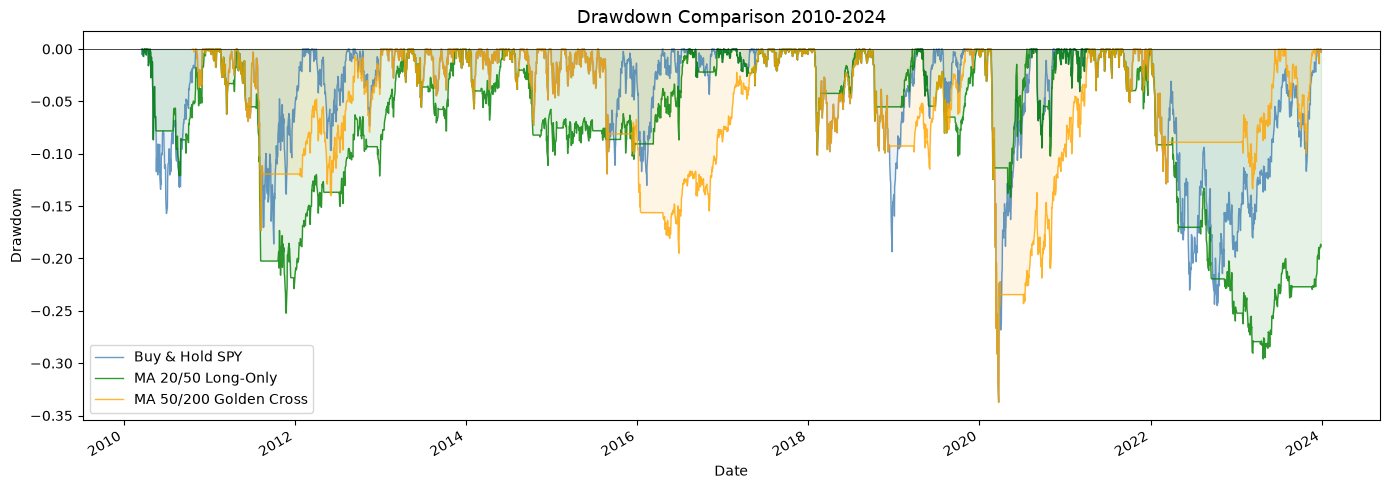

Saved: ./figures/drawdown.png


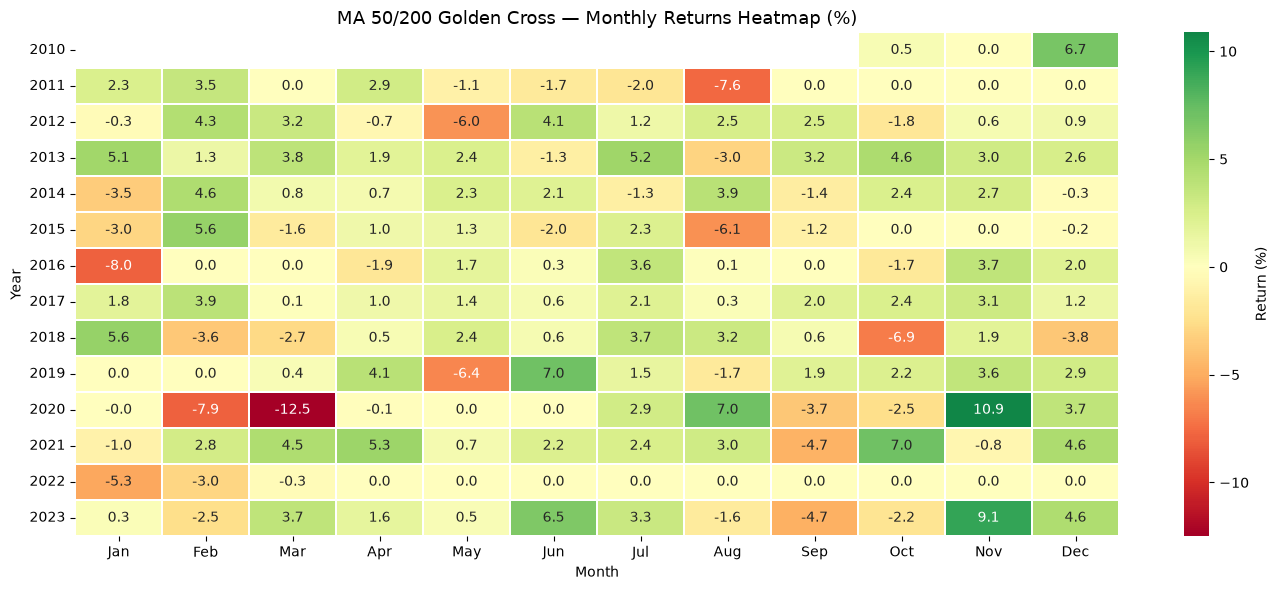

Saved: ./figures/monthly_returns_heatmap.png


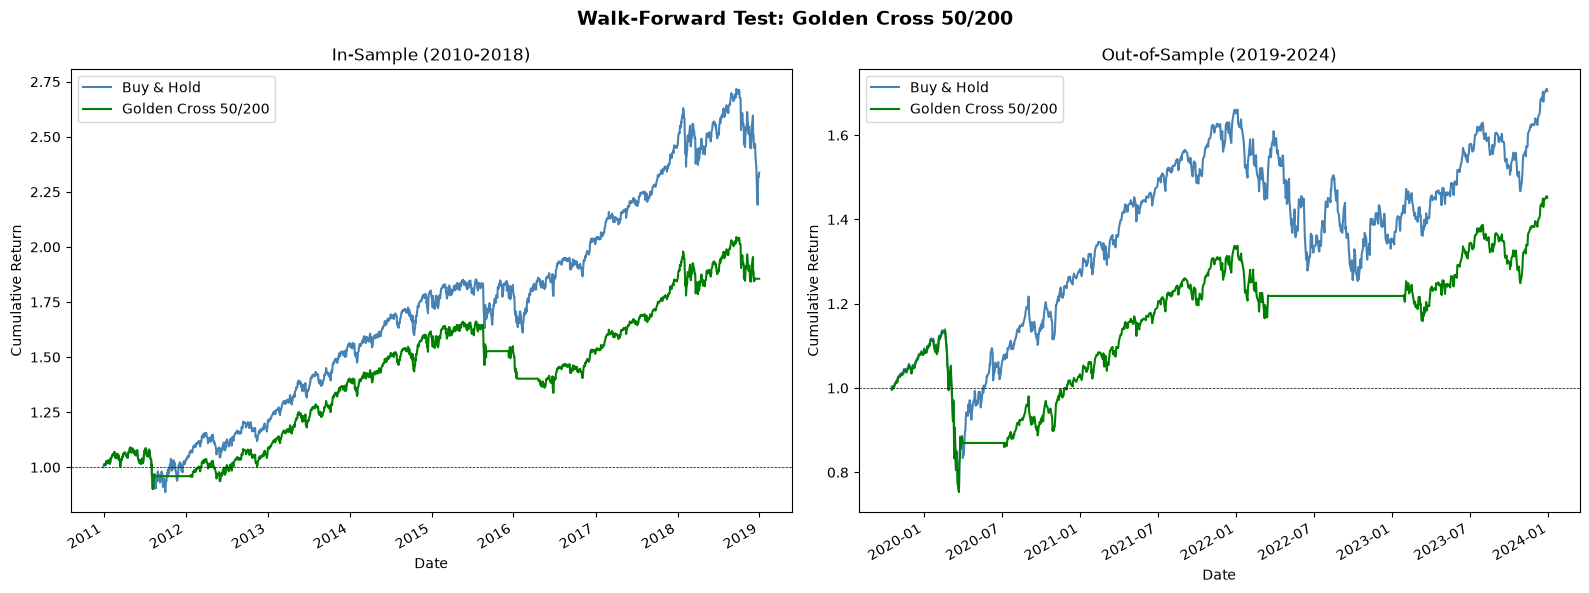

Saved: ./figures/walk_forward_comparison.png


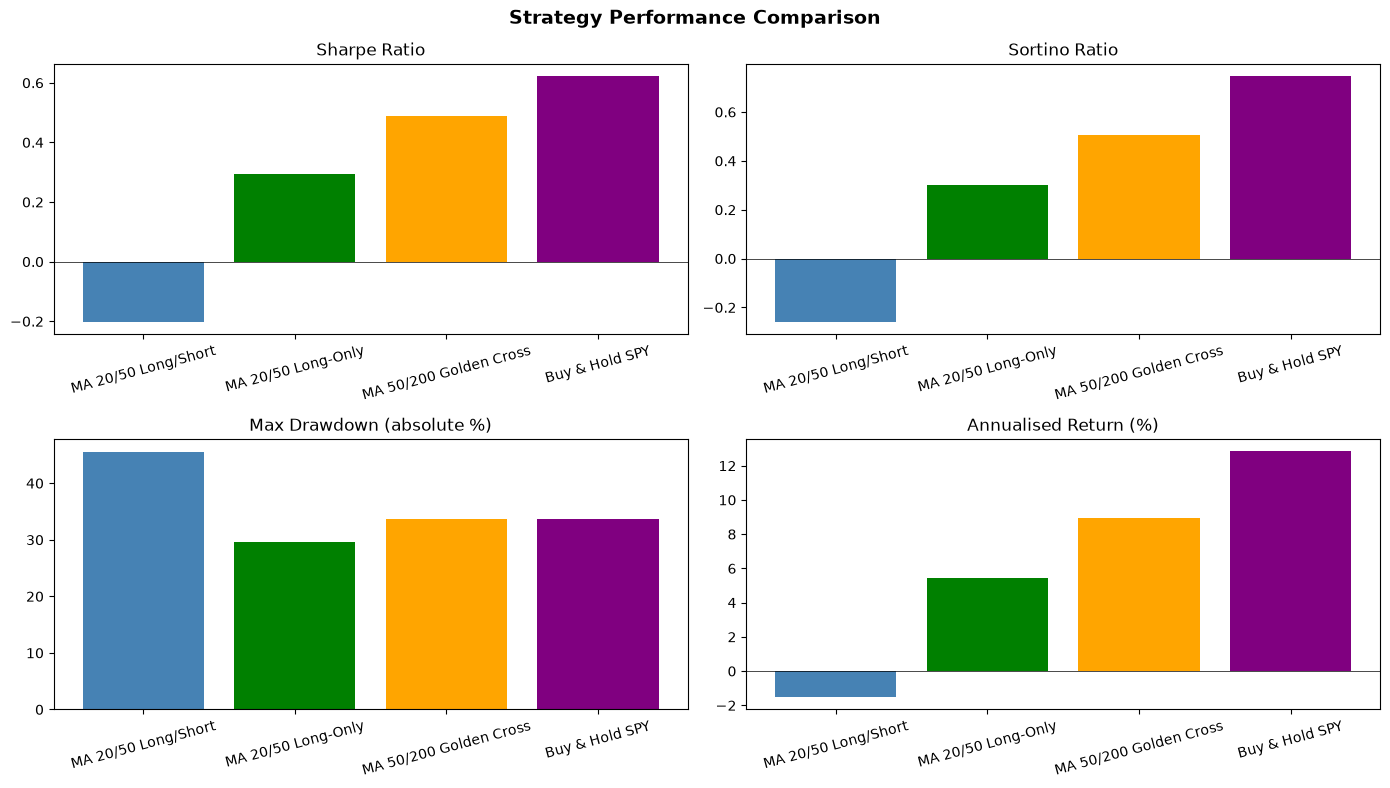

Saved: ./figures/metrics_comparison.png


In [20]:
#Setting save directory

# 1. Price and returns
plot_price_and_returns(df, ticker='SPY', save_dir=SAVE_DIR)

# 2. Returns distribution
plot_returns_distribution(df, ticker='SPY', save_dir=SAVE_DIR)

# 3. Signals — Golden Cross as primary strategy
plot_signals(df_features_200, fast=50, slow=200, 
             ticker='SPY', save_dir=SAVE_DIR)

# 4. Cumulative returns comparison
plot_cumulative_returns({
    'Buy & Hold SPY': results,
    'MA 20/50 Long-Only': results_long_only,
    'MA 50/200 Golden Cross': results_golden
},
    save_dir=SAVE_DIR,
    title='Cumulative Returns: Strategy Comparison 2010-2024'
)

# 5. Drawdown comparison
plot_drawdown({
    'Buy & Hold SPY': results,
    'MA 20/50 Long-Only': results_long_only,
    'MA 50/200 Golden Cross': results_golden
},
    save_dir=SAVE_DIR,
    title='Drawdown Comparison 2010-2024'
)

# 6. Monthly returns heatmap for Golden Cross
plot_monthly_returns_heatmap(
    results_golden,
    label='MA 50/200 Golden Cross',
    save_dir=SAVE_DIR
)

# 7. Walk-forward comparison
plot_walk_forward_comparison(
    results_in,
    results_out,
    label='Golden Cross 50/200',
    save_dir=SAVE_DIR
)

# 8. Metrics comparison bar charts
plot_metrics_comparison(
    [metrics_ls, metrics_lo, metrics_gc, metrics_bh],
    save_dir=SAVE_DIR
)

## 9. Conclusions

**Key findings:**

1. SPY price is non-stationary (ADF p = 0.99, Hurst H = 0.41) — a momentum strategy is statistically justified over mean reversion

2. The MA 20/50 long/short strategy failed (-19.1%) due to costly short positions and excessive whipsawing (70 trades, 14% total transaction costs)

3. Switching to long-only (107.8%) and extending windows to 50/200 (210.1%) progressively improved performance by reducing transaction costs from 70 trades to just 6

4. All strategies underperform buy and hold on raw returns (428%), though the gap narrows significantly on risk-adjusted metrics

5. The Golden Cross retains 84% of its in-sample Sharpe ratio out-of-sample (0.490 → 0.410), demonstrating genuine robustness across different market regimes

6. Monte Carlo simulation tests confirm that this strategy has genuine robustness and that observed historical performnace is very unlikely to be random. *Note: Despite this, this does not guarantee that the strategy will continue to perform in future market regimes.*

---
### Final Results Table: ###

### Summary Results Table

| Strategy | Total Return | Sharpe | Sortino | Max DD | Trades |
|---|---|---|---|---|---|
| MA 20/50 Long/Short | -19.1% | -0.202 | -0.259 | -45.5% | 70 |
| MA 20/50 Long-Only | 107.8% | 0.295 | 0.301 | -29.6% | 35 |
| MA 50/200 Golden Cross | 210.1% | 0.490 | 0.504 | -33.7% | 6 |
| Buy & Hold SPY | 428.0% | 0.623 | 0.747 | -33.7% | 0 |

### Walk-Forward Summary

| Metric | In-Sample (2010-2018) | Out-of-Sample (2019-2024) |
|---|---|---|
| Sharpe Ratio | 0.490 | 0.410 |
| Sortino Ratio | 0.547 | 0.384 |
| Annualised Return | 8.0% | 9.3% |
| Max Drawdown | -19.5% | -33.7% |
| Win Rate | 54.9% | 56.1% |

### Monte Carlo Significance

| Period | p-value | Significant |
|---|---|---|
| In-sample (2010-2018) | 0.0002 | Yes (p < 0.05) |
| Out-of-sample (2019-2024) | 0.0213 | Yes (p < 0.05) |

---


## References

- Chan, E. (2013). *Algorithmic Trading: Winning Strategies and Their Rationale*. Wiley.
- Dickey, D.A. and Fuller, W.A. (1979). Distribution of the Estimators for Autoregressive Time Series With a Unit Root. *Journal of the American Statistical Association*, 74(366), 427-431.
- Hull, J.C. (2018). *Options, Futures, and Other Derivatives*, 10th ed. Pearson.
- Jegadeesh, N. and Titman, S. (1993). Returns to Buying Winners and Selling Losers. *Journal of Finance*, 48(1), 65-91.
- Kissell, R. (2013). *The Science of Algorithmic Trading and Portfolio Management*. Academic Press.
- López de Prado, M. (2018). *Advances in Financial Machine Learning*. Wiley.
- Magdon-Ismail, M. and Atiya, A. (2004). Maximum Drawdown. *Risk Magazine*, 17(10), 99-102.
- Murphy, J.J. (1999). *Technical Analysis of the Financial Markets*. New York Institute of Finance.
- Sharpe, W.F. (1994). The Sharpe Ratio. *Journal of Portfolio  Management*, 21(1), 49-58.
- Sortino, F.A. and van der Meer, R. (1991). Downside Risk.  *Journal of Portfolio Management*, 17(4), 27-31.
- Young, T.W. (1991). Calmar Ratio: A Smoother Tool. *Futures Magazine*, 20(1)